# 1. Problem Statement
🏠 House Price Prediction

🎯 Objective
The goal of this notebook is to build a machine learning model to predict house prices based on various features such as area, number of rooms, and location.

📌 Dataset Overview
We will use a cleaned dataset and focus on preprocessing, feature engineering, and modeling.

# 2. Import Libiraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from category_encoders import BinaryEncoder
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV ,cross_val_score , cross_validate, train_test_split, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import timeit
import os
from pathlib import Path
import joblib
from sklearn.base import clone
from sklearn.ensemble import VotingRegressor

# 3. Load Data

In [2]:
# Determining the data path
BASE_DIR = Path.cwd()
while not (BASE_DIR / "dataset").exists():
    BASE_DIR = BASE_DIR.parent
data_path = BASE_DIR / "dataset" / "clean_house_prices_df.csv"

df = pd.read_csv(data_path)
df.head()

,Amount(in rupees),location,Status,Transaction,Furnishing,facing,Bathroom,Balcony,Ownership,Super Area,BHK,Current_Floor,Total_Floors,View_Garden_Park,View_Main_Road,View_Pool,View_Unknown
0,9000000.0,agra,Ready to Move,New Property,Furnished,Unknown,3,3,Freehold,1600.000000,3,1,4,0,1,0,0
1,4700000.0,agra,Ready to Move,Resale,Semi-Furnished,East,2,1,Freehold,1500.159591,2,7,12,1,1,0,0
2,3000000.0,agra,Ready to Move,Resale,Semi-Furnished,East,2,2,Freehold,1299.826690,2,0,4,1,0,0,0
3,4600000.0,agra,Ready to Move,Resale,Furnished,Unknown,2,0,Unknown,1250.000000,2,1,3,0,0,0,1
4,7000000.0,agra,Ready to Move,Resale,Semi-Furnished,East,3,2,Freehold,1760.120694,4,2,2,1,0,0,0


# 4. Quick Exploration

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52348 entries, 0 to 52347
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Amount(in rupees)  52348 non-null  float64
 1   location           52348 non-null  object 
 2   Status             52348 non-null  object 
 3   Transaction        52348 non-null  object 
 4   Furnishing         52348 non-null  object 
 5   facing             52348 non-null  object 
 6   Bathroom           52348 non-null  int64  
 7   Balcony            52348 non-null  int64  
 8   Ownership          52348 non-null  object 
 9   Super Area         52348 non-null  float64
 10  BHK                52348 non-null  int64  
 11  Current_Floor      52348 non-null  int64  
 12  Total_Floors       52348 non-null  int64  
 13  View_Garden_Park   52348 non-null  int64  
 14  View_Main_Road     52348 non-null  int64  
 15  View_Pool          52348 non-null  int64  
 16  View_Unknown       523

,Amount(in rupees),Bathroom,Balcony,Super Area,BHK,Current_Floor,Total_Floors,View_Garden_Park,View_Main_Road,View_Pool,View_Unknown
count,5.234800e+04,52348.000000,52348.000000,52348.000000,52348.000000,52348.000000,52348.000000,52348.000000,52348.000000,52348.000000,52348.000000
mean,8.247232e+06,2.325533,1.537213,1333.989432,2.473772,4.269198,8.511175,0.402174,0.440991,0.135994,0.401429
std,7.570018e+06,0.758087,1.217329,538.416341,0.748850,4.164452,6.617331,0.490341,0.496510,0.342785,0.490192
min,2.000000e+05,1.000000,0.000000,55.000000,1.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000e+06,2.000000,0.000000,976.429447,2.000000,2.000000,4.000000,0.000000,0.000000,0.000000,0.000000
50%,6.020000e+06,2.000000,2.000000,1250.000000,2.000000,3.000000,5.000000,0.000000,0.000000,0.000000,0.000000
75%,9.500000e+06,3.000000,2.000000,1639.897238,3.000000,5.000000,12.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000e+08,10.000000,10.000000,4366.074349,10.000000,40.000000,91.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
# drop unnecessary column
df = df.drop("Status", axis=1).reset_index(drop=True)

In [5]:
df.shape

(52348, 16)

# 5. Train Test Split

In [6]:
# spliting the features and target
X = df.drop(columns=["Amount(in rupees)"],axis=1)
y = df["Amount(in rupees)"]

# split training and test data
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 6. Preprocessing Pipeline

In [7]:
## Categorical Cardinality Analysis
cat_cols = df.select_dtypes(include="O")
for col in cat_cols.columns:
    print(f"{col} : {df[col].nunique()}")
    print("_"*50)

location : 81
__________________________________________________
Transaction : 3
__________________________________________________
Furnishing : 3
__________________________________________________
facing : 9
__________________________________________________
Ownership : 5
__________________________________________________


In [8]:
onehot_cols = ["Transaction","Furnishing","Ownership"]
binary_cols = ["location","facing"]
numerical_columns = ["Super Area","Bathroom","Balcony","BHK","Current_Floor","Total_Floors"]

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot_encoder",OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False),onehot_cols),
        ("binary_encoder",BinaryEncoder(),binary_cols),
        ("scaler", RobustScaler(), numerical_columns),
    ],
    remainder="passthrough"
)

print("Processor is ready")

Processor is ready


# 7. Baseline Models (Default)

In [9]:
models = [
    ("LR", LinearRegression()),
    ("KNN", KNeighborsRegressor()),
    ("DT", DecisionTreeRegressor()),
    ("RF", RandomForestRegressor()),
    ("XGB", XGBRegressor())
]

# 8. Train & Compare

In [11]:
scoring = {
    "r2": "r2",
    "neg_mean_squared_error": "neg_mean_squared_error",
    "neg_mean_absolute_error": "neg_mean_absolute_error"
}


all_results = []

for model_name, model in models:
    
    start = timeit.default_timer()
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=True
    )
    
    stop = timeit.default_timer()
    
    result_dict = {
        "Model": model_name,
        "Train R2": scores["train_r2"].mean(),
        "Test R2": scores["test_r2"].mean(),
        "Test MSE": -scores["test_neg_mean_squared_error"].mean(),
        "Test MAE": -scores["test_neg_mean_absolute_error"].mean(),
        "Train RMSE": np.sqrt(-scores["train_neg_mean_squared_error"].mean()),
        "Test RMSE": np.sqrt(-scores["test_neg_mean_squared_error"].mean()),
        "Time (sec)": stop - start
    }
    
    all_results.append(result_dict)

df_results = pd.DataFrame(all_results)

df_results = df_results.sort_values(by="Test R2", ascending=False)

df_results

,Model,Train R2,Test R2,Test MSE,Test MAE,Train RMSE,Test RMSE,Time (sec)
3,RF,0.973748,0.818477,1.021563e+13,1.783331e+06,1.217281e+06,3.196190e+06,185.849706
4,XGB,0.889948,0.806293,1.091419e+13,1.919758e+06,2.492090e+06,3.303664e+06,2.960163
1,KNN,0.826921,0.733660,1.502436e+13,2.175983e+06,3.125149e+06,3.876127e+06,28.818356
2,DT,0.999788,0.631380,2.074603e+13,2.398113e+06,1.093359e+05,4.554781e+06,6.644178
0,LR,0.501903,0.501907,2.807390e+13,3.278940e+06,5.302358e+06,5.298481e+06,1.175990


##### 📈 Results Summary

From the evaluation results:
Random Forest (RF) achieved the highest performance with:
Highest R² score
Lowest MAE
XGBoost (XGB) came in second with very competitive performance and significantly faster training time compared to Random Forest.

✅ Model Selection

Based on the comparison:
We selected Random Forest and XGBoost as the top-performing models.
These models will be further improved through hyperparameter tuning to enhance their performance.

# 9. Experiments

In [10]:
# =========================
# Collect All Results
# =========================
results = []

def add_result(name, train_r2, test_r2, train_mae, test_mae, train_rmse, test_rmse):
    results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

## 9.1 XGBoost

In [11]:
# Pipeline
xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42))
])

### 1. Outliers Removal

In [12]:

# =========================
# 1. Remove Outliers
# =========================
Q1 = df["Amount(in rupees)"].quantile(0.25)
Q3 = df["Amount(in rupees)"].quantile(0.75)
IQR = Q3 - Q1

df_out = df[
    (df["Amount(in rupees)"] >= Q1 - 1.5 * IQR) &
    (df["Amount(in rupees)"] <= Q3 + 1.5 * IQR)
]

# =========================
# 2. Split
# =========================
X_out = df_out.drop(columns=["Amount(in rupees)"])
y_out = df_out["Amount(in rupees)"]

X_train_out, X_test_out, y_train_out, y_test_out = train_test_split(
    X_out, y_out, test_size=0.2, random_state=42
)

# =========================
# 3. Train
# =========================
xgb_pipe.fit(X_train_out, y_train_out)

# =========================
# 4. Predictions
# =========================
train_preds_out = xgb_pipe.predict(X_train_out)
test_preds_out = xgb_pipe.predict(X_test_out)

# =========================
# 5. R2 Score
# =========================
train_r2_out = r2_score(y_train_out, train_preds_out)
test_r2_out = r2_score(y_test_out, test_preds_out)

# =========================
# 6. Metrics
# =========================
train_mae_out = mean_absolute_error(y_train_out, train_preds_out)
test_mae_out = mean_absolute_error(y_test_out, test_preds_out)

train_rmse_out = np.sqrt(mean_squared_error(y_train_out, train_preds_out))
test_rmse_out = np.sqrt(mean_squared_error(y_test_out, test_preds_out))

# =========================
# 7. Print
# =========================
print("📊 AFTER Removing Outliers")
print("🔹 Train R2:", train_r2_out)
print("🔹 Test R2 :", test_r2_out)
print("-"*50)

print("🔹 Train MAE :", train_mae_out)
print("🔹 Test MAE  :", test_mae_out)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_out)
print("🔹 Test RMSE :", test_rmse_out)

add_result("XGB - Remove Outliers", train_r2_out, test_r2_out, train_mae_out, test_mae_out, train_rmse_out, test_rmse_out)

📊 AFTER Removing Outliers
🔹 Train R2: 0.8055418673872223
🔹 Test R2 : 0.7389810395003487
--------------------------------------------------
🔹 Train MAE : 1133697.041502931
🔹 Test MAE  : 1311785.3851281253
--------------------------------------------------
🔹 Train RMSE: 1575282.8813317458
🔹 Test RMSE : 1837423.3175316425


### 2. Log Transformation

In [13]:
# =========================
# 1. Apply Log Transformation
# =========================
y_log = np.log1p(y)

# =========================
# 2. Train Test Split (New)
# =========================
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# =========================
# 3. Train Model
# =========================
xgb_pipe.fit(X_train_log, y_train_log)

# =========================
# 4. Predictions (Log Space)
# =========================
train_preds_log = xgb_pipe.predict(X_train_log)
test_preds_log = xgb_pipe.predict(X_test_log)

# =========================
# 5. Convert Back to Normal Scale
# =========================
train_preds_log = np.expm1(train_preds_log)
test_preds_log = np.expm1(test_preds_log)

y_train_original = np.expm1(y_train_log)
y_test_original = np.expm1(y_test_log)

# =========================
# 6. Evaluation
# =========================
train_mae_log = mean_absolute_error(y_train_original, train_preds_log)
test_mae_log = mean_absolute_error(y_test_original, test_preds_log)

train_rmse_log = np.sqrt(mean_squared_error(y_train_original, train_preds_log))
test_rmse_log = np.sqrt(mean_squared_error(y_test_original, test_preds_log))

# =========================
# 7. R2 Score
# =========================
train_r2_log = r2_score(y_train_original, train_preds_log)
test_r2_log = r2_score(y_test_original, test_preds_log)

# =========================
# 8. Print Results
# =========================
print("📊 LOG Transformation Results")

print("🔹 Train R2 :", train_r2_log)
print("🔹 Test R2  :", test_r2_log)
print("-"*50)

print("🔹 Train MAE :", train_mae_log)
print("🔹 Test MAE  :", test_mae_log)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_log)
print("🔹 Test RMSE :", test_rmse_log)

add_result("XGB - Log Transformation", train_r2_log, test_r2_log, train_mae_log, test_mae_log, train_rmse_log, test_rmse_log)

📊 LOG Transformation Results
🔹 Train R2 : 0.8649092965135221
🔹 Test R2  : 0.8100598128954746
--------------------------------------------------
🔹 Train MAE : 1552983.9380387678
🔹 Test MAE  : 1844338.315234002
--------------------------------------------------
🔹 Train RMSE: 2761082.482201904
🔹 Test RMSE : 3397818.59749497


### 3. Capping

In [14]:
# =========================
# 1. Copy Data
# =========================
df_cap = df.copy()

# =========================
# 2. Apply Capping (99%)
# =========================
lower = df_cap["Amount(in rupees)"].quantile(0.01)
upper = df_cap["Amount(in rupees)"].quantile(0.99)

df_cap["Amount(in rupees)"] = df_cap["Amount(in rupees)"].clip(lower, upper)

# =========================
# 3. Split
# =========================
X_cap = df_cap.drop(columns=["Amount(in rupees)"])
y_cap = df_cap["Amount(in rupees)"]

X_train_cap, X_test_cap, y_train_cap, y_test_cap = train_test_split(
    X_cap, y_cap, test_size=0.2, random_state=42
)

# =========================
# 4. Train
# =========================
xgb_pipe.fit(X_train_cap, y_train_cap)

# =========================
# 5. Predictions
# =========================
train_preds_cap = xgb_pipe.predict(X_train_cap)
test_preds_cap = xgb_pipe.predict(X_test_cap)

# =========================
# 6. R2 Score
# =========================
train_r2_cap = r2_score(y_train_cap, train_preds_cap)
test_r2_cap = r2_score(y_test_cap, test_preds_cap)

# =========================
# 7. Metrics
# =========================
train_mae_cap = mean_absolute_error(y_train_cap, train_preds_cap)
test_mae_cap = mean_absolute_error(y_test_cap, test_preds_cap)

train_rmse_cap = np.sqrt(mean_squared_error(y_train_cap, train_preds_cap))
test_rmse_cap = np.sqrt(mean_squared_error(y_test_cap, test_preds_cap))

# =========================
# 8. Print
# =========================
print("📊 CAPPING (99%) Results")

print("🔹 Train R2 :", train_r2_cap)
print("🔹 Test R2  :", test_r2_cap)
print("-"*50)

print("🔹 Train MAE :", train_mae_cap)
print("🔹 Test MAE  :", test_mae_cap)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_cap)
print("🔹 Test RMSE :", test_rmse_cap)

add_result("XGB - Capping", train_r2_cap, test_r2_cap, train_mae_cap, test_mae_cap, train_rmse_cap, test_rmse_cap)

📊 CAPPING (99%) Results
🔹 Train R2 : 0.8802635782421211
🔹 Test R2  : 0.8292591273427123
--------------------------------------------------
🔹 Train MAE : 1532661.2355444592
🔹 Test MAE  : 1806068.209652952
--------------------------------------------------
🔹 Train RMSE: 2349130.527244626
🔹 Test RMSE : 2869017.051175764


### 4. Feature Engineering

In [15]:
df_fe = df.copy()

df_fe["area_per_bhk"] = df_fe["Super Area"] / df_fe["BHK"]
df_fe["bathroom_per_bhk"] = df_fe["Bathroom"] / df_fe["BHK"]
df_fe["balcony_per_bhk"] = df_fe["Balcony"] / df_fe["BHK"]

X_fe = df_fe.drop(columns=["Amount(in rupees)"])
y_fe = df_fe["Amount(in rupees)"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42
)

xgb_pipe.fit(X_train_fe,y_train_fe)

train_preds_fe = xgb_pipe.predict(X_train_fe)
test_preds_fe = xgb_pipe.predict(X_test_fe)

train_r2_fe = r2_score(y_train_fe, train_preds_fe)
test_r2_fe = r2_score(y_test_fe, test_preds_fe)

train_mae_fe = mean_absolute_error(y_train_fe, train_preds_fe)
test_mae_fe = mean_absolute_error(y_test_fe, test_preds_fe)

train_rmse_fe = np.sqrt(mean_squared_error(y_train_fe, train_preds_fe))
test_rmse_fe = np.sqrt(mean_squared_error(y_test_fe, test_preds_fe))

print("📊 Feature Engineering Results")
print("🔹 Train R2 :", train_r2_fe)
print("🔹 Test R2  :", test_r2_fe)
print("-"*50)

print("🔹 Train MAE :", train_mae_fe)
print("🔹 Test MAE  :", test_mae_fe)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_fe)
print("🔹 Test RMSE :", test_rmse_fe)

add_result("XGB - Feature Engineering", train_r2_fe, test_r2_fe, train_mae_fe, test_mae_fe, train_rmse_fe, test_rmse_fe)

📊 Feature Engineering Results
🔹 Train R2 : 0.8892469653106027
🔹 Test R2  : 0.8222834091779644
--------------------------------------------------
🔹 Train MAE : 1583164.7053253963
🔹 Test MAE  : 1912711.221666816
--------------------------------------------------
🔹 Train RMSE: 2500025.660906919
🔹 Test RMSE : 3286667.3087693932


### 5. Build More One  Model

In [16]:
# Split Data (Cheap vs Expensive)
PRICE_THRESHOLD = 9_500_000
cheap_df = df[df["Amount(in rupees)"] <= PRICE_THRESHOLD]
expensive_df = df[df["Amount(in rupees)"] > PRICE_THRESHOLD]

# Features & Target
X_cheap = cheap_df.drop(columns=["Amount(in rupees)"])
y_cheap = cheap_df["Amount(in rupees)"]

X_exp = expensive_df.drop(columns=["Amount(in rupees)"])
y_exp = expensive_df["Amount(in rupees)"]

X_train_cheap, X_test_cheap, y_train_cheap, y_test_cheap = train_test_split(
    X_cheap, y_cheap, test_size=0.2, random_state=42
)

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42
)

# Clone Models 
model_cheap = clone(xgb_pipe)
model_exp = clone(xgb_pipe)

# Training
model_cheap.fit(X_train_cheap, y_train_cheap)
model_exp.fit(X_train_exp, y_train_exp)

# Predictions
train_cheap_pred = model_cheap.predict(X_train_cheap)
test_cheap_pred = model_cheap.predict(X_test_cheap)

train_exp_pred = model_exp.predict(X_train_exp)
test_exp_pred = model_exp.predict(X_test_exp)

# ===============================
# CHEAP MODEL RESULTS
# ===============================
print("\n" + "="*50)
print("🏠 CHEAP MODEL")
print("="*50)

# Train
train_r2_cheap = r2_score(y_train_cheap, train_cheap_pred)
train_mae_cheap = mean_absolute_error(y_train_cheap, train_cheap_pred)
train_rmse_cheap = np.sqrt(mean_squared_error(y_train_cheap, train_cheap_pred))

# Test
test_r2_cheap = r2_score(y_test_cheap, test_cheap_pred)
test_mae_cheap = mean_absolute_error(y_test_cheap, test_cheap_pred)
test_rmse_cheap = np.sqrt(mean_squared_error(y_test_cheap, test_cheap_pred))

print("📊 Cheap Model Results")
print("🔹 Train R2 :", train_r2_cheap)
print("🔹 Test R2  :", test_r2_cheap)
print("-"*50)

print("🔹 Train MAE :", train_mae_cheap)
print("🔹 Test MAE  :", test_mae_cheap)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_cheap)
print("🔹 Test RMSE :", test_rmse_cheap)


# ===============================
# EXPENSIVE MODEL RESULTS
# ===============================
print("\n" + "="*50)
print("🏠 EXPENSIVE MODEL")
print("="*50)

# Train
train_r2_exp = r2_score(y_train_exp, train_exp_pred)
train_mae_exp = mean_absolute_error(y_train_exp, train_exp_pred)
train_rmse_exp = np.sqrt(mean_squared_error(y_train_exp, train_exp_pred))

# Test
test_r2_exp = r2_score(y_test_exp, test_exp_pred)
test_mae_exp = mean_absolute_error(y_test_exp, test_exp_pred)
test_rmse_exp = np.sqrt(mean_squared_error(y_test_exp, test_exp_pred))

print("📊 Expensive Model Results")
print("🔹 Train R2 :", train_r2_exp)
print("🔹 Test R2  :", test_r2_exp)
print("-"*50)

print("🔹 Train MAE :", train_mae_exp)
print("🔹 Test MAE  :", test_mae_exp)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_exp)
print("🔹 Test RMSE :", test_rmse_exp)

add_result("XGB - CHEAP MODEL", train_r2_cheap, test_r2_cheap, train_mae_cheap, test_mae_cheap, train_rmse_cheap, test_rmse_cheap)
add_result("XGB - EXPENSIVE MODEL", train_r2_exp, test_r2_exp, train_mae_exp, test_mae_exp, train_rmse_exp, test_rmse_exp)


🏠 CHEAP MODEL
📊 Cheap Model Results
🔹 Train R2 : 0.7637908651944743
🔹 Test R2  : 0.6901178685608063
--------------------------------------------------
🔹 Train MAE : 782580.9248298331
🔹 Test MAE  : 895126.2087210765
--------------------------------------------------
🔹 Train RMSE: 1020260.8343627836
🔹 Test RMSE : 1157353.1441095297

🏠 EXPENSIVE MODEL
📊 Expensive Model Results
🔹 Train R2 : 0.892220861017335
🔹 Test R2  : 0.7112930867083562
--------------------------------------------------
🔹 Train MAE : 2283699.027355774
🔹 Test MAE  : 3464677.788324067
--------------------------------------------------
🔹 Train RMSE: 3317370.9535886096
🔹 Test RMSE : 5380906.492687643


## 9.2 RandomForest

In [53]:
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

### 1. Outliers Removal

In [54]:

# =========================
# 1. Remove Outliers
# =========================
Q1 = df["Amount(in rupees)"].quantile(0.25)
Q3 = df["Amount(in rupees)"].quantile(0.75)
IQR = Q3 - Q1

df_out = df[
    (df["Amount(in rupees)"] >= Q1 - 1.5 * IQR) &
    (df["Amount(in rupees)"] <= Q3 + 1.5 * IQR)
]

# =========================
# 2. Split
# =========================
X_out = df_out.drop(columns=["Amount(in rupees)"])
y_out = df_out["Amount(in rupees)"]

X_train_out, X_test_out, y_train_out, y_test_out = train_test_split(
    X_out, y_out, test_size=0.2, random_state=42
)

# =========================
# 3. Train
# =========================
rf_pipe.fit(X_train_out, y_train_out)

# =========================
# 4. Predictions
# =========================
train_preds_out = rf_pipe.predict(X_train_out)
test_preds_out = rf_pipe.predict(X_test_out)

# =========================
# 5. R2 Score
# =========================
train_r2_out = r2_score(y_train_out, train_preds_out)
test_r2_out = r2_score(y_test_out, test_preds_out)

# =========================
# 6. Metrics
# =========================
train_mae_out = mean_absolute_error(y_train_out, train_preds_out)
test_mae_out = mean_absolute_error(y_test_out, test_preds_out)

train_rmse_out = np.sqrt(mean_squared_error(y_train_out, train_preds_out))
test_rmse_out = np.sqrt(mean_squared_error(y_test_out, test_preds_out))

# =========================
# 7. Print
# =========================
print("📊 AFTER Removing Outliers")
print("🔹 Train R2:", train_r2_out)
print("🔹 Test R2 :", test_r2_out)
print("-"*50)

print("🔹 Train MAE :", train_mae_out)
print("🔹 Test MAE  :", test_mae_out)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_out)
print("🔹 Test RMSE :", test_rmse_out)

add_result("RF - Remove Outliers", train_r2_out, test_r2_out, train_mae_out, test_mae_out, train_rmse_out, test_rmse_out)

📊 AFTER Removing Outliers
🔹 Train R2: 0.9676831260587375
🔹 Test R2 : 0.7751809786842245
--------------------------------------------------
🔹 Train MAE : 444602.8703643589
🔹 Test MAE  : 1188712.6084116446
--------------------------------------------------
🔹 Train RMSE: 642185.019191927
🔹 Test RMSE : 1705256.5328328342


### 2. Log Transformation

In [55]:
# =========================
# 1. Apply Log Transformation
# =========================
y_log = np.log1p(y)

# =========================
# 2. Train Test Split (New)
# =========================
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# =========================
# 3. Train Model
# =========================
rf_pipe.fit(X_train_log, y_train_log)

# =========================
# 4. Predictions (Log Space)
# =========================
train_preds_log = rf_pipe.predict(X_train_log)
test_preds_log = rf_pipe.predict(X_test_log)

# =========================
# 5. Convert Back to Normal Scale
# =========================
train_preds_log = np.expm1(train_preds_log)
test_preds_log = np.expm1(test_preds_log)

y_train_original = np.expm1(y_train_log)
y_test_original = np.expm1(y_test_log)

# =========================
# 6. Evaluation
# =========================
train_mae_log = mean_absolute_error(y_train_original, train_preds_log)
test_mae_log = mean_absolute_error(y_test_original, test_preds_log)

train_rmse_log = np.sqrt(mean_squared_error(y_train_original, train_preds_log))
test_rmse_log = np.sqrt(mean_squared_error(y_test_original, test_preds_log))

# =========================
# 7. R2 Score
# =========================
train_r2_log = r2_score(y_train_original, train_preds_log)
test_r2_log = r2_score(y_test_original, test_preds_log)

# =========================
# 8. Print Results
# =========================
print("📊 LOG Transformation Results")

print("🔹 Train R2 :", train_r2_log)
print("🔹 Test R2  :", test_r2_log)
print("-"*50)

print("🔹 Train MAE :", train_mae_log)
print("🔹 Test MAE  :", test_mae_log)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_log)
print("🔹 Test RMSE :", test_rmse_log)

add_result("RF - Log Transformation", train_r2_log, test_r2_log, train_mae_log, test_mae_log, train_rmse_log, test_rmse_log)

📊 LOG Transformation Results
🔹 Train R2 : 0.9650381828036008
🔹 Test R2  : 0.8152161130554302
--------------------------------------------------
🔹 Train MAE : 659069.1573315185
🔹 Test MAE  : 1729397.4926048673
--------------------------------------------------
🔹 Train RMSE: 1404635.5240564244
🔹 Test RMSE : 3351381.0331074474


### 3. Capping

In [56]:
# =========================
# 1. Copy Data
# =========================
df_cap = df.copy()

# =========================
# 2. Apply Capping (99%)
# =========================
lower = df_cap["Amount(in rupees)"].quantile(0.01)
upper = df_cap["Amount(in rupees)"].quantile(0.99)

df_cap["Amount(in rupees)"] = df_cap["Amount(in rupees)"].clip(lower, upper)

# =========================
# 3. Split
# =========================
X_cap = df_cap.drop(columns=["Amount(in rupees)"])
y_cap = df_cap["Amount(in rupees)"]

X_train_cap, X_test_cap, y_train_cap, y_test_cap = train_test_split(
    X_cap, y_cap, test_size=0.2, random_state=42
)

# =========================
# 4. Train
# =========================
rf_pipe.fit(X_train_cap, y_train_cap)

# =========================
# 5. Predictions
# =========================
train_preds_cap = rf_pipe.predict(X_train_cap)
test_preds_cap = rf_pipe.predict(X_test_cap)

# =========================
# 6. R2 Score
# =========================
train_r2_cap = r2_score(y_train_cap, train_preds_cap)
test_r2_cap = r2_score(y_test_cap, test_preds_cap)

# =========================
# 7. Metrics
# =========================
train_mae_cap = mean_absolute_error(y_train_cap, train_preds_cap)
test_mae_cap = mean_absolute_error(y_test_cap, test_preds_cap)

train_rmse_cap = np.sqrt(mean_squared_error(y_train_cap, train_preds_cap))
test_rmse_cap = np.sqrt(mean_squared_error(y_test_cap, test_preds_cap))

# =========================
# 8. Print
# =========================
print("📊 CAPPING (99%) Results")

print("🔹 Train R2 :", train_r2_cap)
print("🔹 Test R2  :", test_r2_cap)
print("-"*50)

print("🔹 Train MAE :", train_mae_cap)
print("🔹 Test MAE  :", test_mae_cap)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_cap)
print("🔹 Test RMSE :", test_rmse_cap)

add_result("RF - Capping", train_r2_cap, test_r2_cap, train_mae_cap, test_mae_cap, train_rmse_cap, test_rmse_cap)

📊 CAPPING (99%) Results
🔹 Train R2 : 0.9771361298789971
🔹 Test R2  : 0.8370762263391814
--------------------------------------------------
🔹 Train MAE : 617039.7210512613
🔹 Test MAE  : 1669383.796695334
--------------------------------------------------
🔹 Train RMSE: 1026523.4694820041
🔹 Test RMSE : 2802570.919705572


### 4. Feature Engineering

In [57]:
df_fe = df.copy()

df_fe["area_per_bhk"] = df_fe["Super Area"] / df_fe["BHK"]
df_fe["bathroom_per_bhk"] = df_fe["Bathroom"] / df_fe["BHK"]
df_fe["balcony_per_bhk"] = df_fe["Balcony"] / df_fe["BHK"]

X_fe = df_fe.drop(columns=["Amount(in rupees)"])
y_fe = df_fe["Amount(in rupees)"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42
)

rf_pipe.fit(X_train_fe,y_train_fe)

train_preds_fe = rf_pipe.predict(X_train_fe)
test_preds_fe = rf_pipe.predict(X_test_fe)

train_r2_fe = r2_score(y_train_fe, train_preds_fe)
test_r2_fe = r2_score(y_test_fe, test_preds_fe)

train_mae_fe = mean_absolute_error(y_train_fe, train_preds_fe)
test_mae_fe = mean_absolute_error(y_test_fe, test_preds_fe)

train_rmse_fe = np.sqrt(mean_squared_error(y_train_fe, train_preds_fe))
test_rmse_fe = np.sqrt(mean_squared_error(y_test_fe, test_preds_fe))

print("📊 Feature Engineering Results")
print("🔹 Train R2 :", train_r2_fe)
print("🔹 Test R2  :", test_r2_fe)
print("-"*50)

print("🔹 Train MAE :", train_mae_fe)
print("🔹 Test MAE  :", test_mae_fe)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_fe)
print("🔹 Test RMSE :", test_rmse_fe)

add_result("RF - Feature Engineering", train_r2_fe, test_r2_fe, train_mae_fe, test_mae_fe, train_rmse_fe, test_rmse_fe)

📊 Feature Engineering Results
🔹 Train R2 : 0.9744344743283657
🔹 Test R2  : 0.828312634605044
--------------------------------------------------
🔹 Train MAE : 663033.2422654361
🔹 Test MAE  : 1792218.5174645227
--------------------------------------------------
🔹 Train RMSE: 1201141.0578336564
🔹 Test RMSE : 3230434.401184226


### 5. Build More One  Model

In [58]:
# Split Data (Cheap vs Expensive)
PRICE_THRESHOLD = 9_500_000
cheap_df = df[df["Amount(in rupees)"] <= PRICE_THRESHOLD]
expensive_df = df[df["Amount(in rupees)"] > PRICE_THRESHOLD]

# Features & Target
X_cheap = cheap_df.drop(columns=["Amount(in rupees)"])
y_cheap = cheap_df["Amount(in rupees)"]

X_exp = expensive_df.drop(columns=["Amount(in rupees)"])
y_exp = expensive_df["Amount(in rupees)"]

X_train_cheap, X_test_cheap, y_train_cheap, y_test_cheap = train_test_split(
    X_cheap, y_cheap, test_size=0.2, random_state=42
)

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42
)

# Clone Models 
model_cheap = clone(rf_pipe)
model_exp = clone(rf_pipe)

# Training
model_cheap.fit(X_train_cheap, y_train_cheap)
model_exp.fit(X_train_exp, y_train_exp)

# Predictions
train_cheap_pred = model_cheap.predict(X_train_cheap)
test_cheap_pred = model_cheap.predict(X_test_cheap)

train_exp_pred = model_exp.predict(X_train_exp)
test_exp_pred = model_exp.predict(X_test_exp)

# ===============================
# CHEAP MODEL RESULTS
# ===============================
print("\n" + "="*50)
print("🏠 CHEAP MODEL")
print("="*50)

# Train
train_r2_cheap = r2_score(y_train_cheap, train_cheap_pred)
train_mae_cheap = mean_absolute_error(y_train_cheap, train_cheap_pred)
train_rmse_cheap = np.sqrt(mean_squared_error(y_train_cheap, train_cheap_pred))

# Test
test_r2_cheap = r2_score(y_test_cheap, test_cheap_pred)
test_mae_cheap = mean_absolute_error(y_test_cheap, test_cheap_pred)
test_rmse_cheap = np.sqrt(mean_squared_error(y_test_cheap, test_cheap_pred))

print("📊 Cheap Model Results")
print("🔹 Train R2 :", train_r2_cheap)
print("🔹 Test R2  :", test_r2_cheap)
print("-"*50)

print("🔹 Train MAE :", train_mae_cheap)
print("🔹 Test MAE  :", test_mae_cheap)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_cheap)
print("🔹 Test RMSE :", test_rmse_cheap)


# ===============================
# EXPENSIVE MODEL RESULTS
# ===============================
print("\n" + "="*50)
print("🏠 EXPENSIVE MODEL")
print("="*50)

# Train
train_r2_exp = r2_score(y_train_exp, train_exp_pred)
train_mae_exp = mean_absolute_error(y_train_exp, train_exp_pred)
train_rmse_exp = np.sqrt(mean_squared_error(y_train_exp, train_exp_pred))

# Test
test_r2_exp = r2_score(y_test_exp, test_exp_pred)
test_mae_exp = mean_absolute_error(y_test_exp, test_exp_pred)
test_rmse_exp = np.sqrt(mean_squared_error(y_test_exp, test_exp_pred))

print("📊 Expensive Model Results")
print("🔹 Train R2 :", train_r2_exp)
print("🔹 Test R2  :", test_r2_exp)
print("-"*50)

print("🔹 Train MAE :", train_mae_exp)
print("🔹 Test MAE  :", test_mae_exp)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_exp)
print("🔹 Test RMSE :", test_rmse_exp)

add_result("XGB - CHEAP MODEL", train_r2_cheap, test_r2_cheap, train_mae_cheap, test_mae_cheap, train_rmse_cheap, test_rmse_cheap)
add_result("XGB - EXPENSIVE MODEL", train_r2_exp, test_r2_exp, train_mae_exp, test_mae_exp, train_rmse_exp, test_rmse_exp)


🏠 CHEAP MODEL
📊 Cheap Model Results
🔹 Train R2 : 0.9580669831001664
🔹 Test R2  : 0.7114687498620393
--------------------------------------------------
🔹 Train MAE : 320699.091999854
🔹 Test MAE  : 839683.2922239706
--------------------------------------------------
🔹 Train RMSE: 429873.74949849455
🔹 Test RMSE : 1116770.818713027

🏠 EXPENSIVE MODEL
📊 Expensive Model Results
🔹 Train R2 : 0.9660197853517025
🔹 Test R2  : 0.7490714541973496
--------------------------------------------------
🔹 Train MAE : 1142861.4765167313
🔹 Test MAE  : 3096344.1271417225
--------------------------------------------------
🔹 Train RMSE: 1862686.391857003
🔹 Test RMSE : 5016512.378692415


# 10. Final Model Comparison

In [59]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Test R2", ascending=False)

results_df

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
8,RF - Capping,0.977136,0.837076,6.170397e+05,1.669384e+06,1.026523e+06,2.802571e+06
2,XGB - Capping,0.880264,0.829259,1.532661e+06,1.806068e+06,2.349131e+06,2.869017e+06
9,RF - Feature Engineering,0.974434,0.828313,6.630332e+05,1.792219e+06,1.201141e+06,3.230434e+06
3,XGB - Feature Engineering,0.889247,0.822283,1.583165e+06,1.912711e+06,2.500026e+06,3.286667e+06
7,RF - Log Transformation,0.965038,0.815216,6.590692e+05,1.729397e+06,1.404636e+06,3.351381e+06
1,XGB - Log Transformation,0.864909,0.810060,1.552984e+06,1.844338e+06,2.761082e+06,3.397819e+06
6,RF - Remove Outliers,0.967683,0.775181,4.446029e+05,1.188713e+06,6.421850e+05,1.705257e+06
11,XGB - EXPENSIVE MODEL,0.966020,0.749071,1.142861e+06,3.096344e+06,1.862686e+06,5.016512e+06
0,XGB - Remove Outliers,0.805542,0.738981,1.133697e+06,1.311785e+06,1.575283e+06,1.837423e+06
10,XGB - CHEAP MODEL,0.958067,0.711469,3.206991e+05,8.396833e+05,4.298737e+05,1.116771e+06


# 11. Hyperparameter Tuning

In [19]:
tuning_results = []

def add_tuning_result(name, best_params, cv_score,
                      train_r2, test_r2,
                      train_mae, test_mae,
                      train_rmse, test_rmse):
    
    tuning_results.append({
        "Model": name,
        "Best Params": best_params,
        "Best Score": cv_score,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

## 11.1 XGBoost

### 1. Base Data

In [61]:
# Pipeline
xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42))
])

# Parameter Grid
xgb_param_grid = {
    "model__n_estimators": [100,150, 200],
    "model__max_depth": [3, 6, 10],
    "model__learning_rate": [0.01, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
    
}

# Grid Search
xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_param_grid,
    cv=5,
    scoring="r2",
    return_train_score=True,
    n_jobs=-1,
    verbose=2
)

# Training
xgb_grid.fit(X_train, y_train)

xg_best_model = xgb_grid.best_estimator_

# Best Results
print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB Score:", xgb_grid.best_score_)
print("-"*50)

# predictions
y_pred_train = xg_best_model.predict(X_train)
y_pred_test = xg_best_model.predict(X_test)

#score
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# MAE
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("🔹 Train R2:", train_r2)
print("🔹 Test R2 :", test_r2)
print("-"*50)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)
print("-"*50)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

add_tuning_result(
    "XGB - Base Data",
    xgb_grid.best_params_,
    xgb_grid.best_score_,
    train_r2, test_r2,
    train_mae, test_mae,
    train_rmse, test_rmse
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGB Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best XGB Score: 0.8311688647889259
--------------------------------------------------
🔹 Train R2: 0.9712894523456403
🔹 Test R2 : 0.8450089387615769
--------------------------------------------------
Train MAE: 827596.1294884844
Test MAE: 1710529.2205408309
--------------------------------------------------
Train RMSE: 1272879.7789408944
Test RMSE: 3069340.601408643


### 2. Outliers Removal

In [62]:
# Pipeline
xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42))
])

# Parameter Grid
xgb_param_grid = {
    "model__n_estimators": [100,150, 200],
    "model__max_depth": [3, 6, 10],
    "model__learning_rate": [0.01, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
    
}

# Grid Search
xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_param_grid,
    cv=5,
    scoring="r2",
    return_train_score=True,
    n_jobs=-1,
    verbose=2
)

# Training
xgb_grid.fit(X_train_out, y_train_out)

xg_best_model_out = xgb_grid.best_estimator_

# Best Results
print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB Score:", xgb_grid.best_score_)
print("-"*50)

# predictions
y_pred_train_out = xg_best_model_out.predict(X_train_out)
y_pred_test_out = xg_best_model_out.predict(X_test_out)

#score
train_r2_out = r2_score(y_train_out, y_pred_train_out)
test_r2_out = r2_score(y_test_out, y_pred_test_out)

# MAE
train_mae_out = mean_absolute_error(y_train_out, y_pred_train_out)
test_mae_out = mean_absolute_error(y_test_out, y_pred_test_out)

# RMSE
train_rmse_out = np.sqrt(mean_squared_error(y_train_out, y_pred_train_out))
test_rmse_out = np.sqrt(mean_squared_error(y_test_out, y_pred_test_out))

print("📊 AFTER Removing Outliers")
print("🔹 Train R2:", train_r2_out)
print("🔹 Test R2 :", test_r2_out)
print("-"*50)

print("Train MAE:", train_mae_out)
print("Test MAE:", test_mae_out)
print("-"*50)

print("Train RMSE:", train_rmse_out)
print("Test RMSE:", test_rmse_out)

add_tuning_result(
    "XGB -  Outliers Removal",
    xgb_grid.best_params_,
    xgb_grid.best_score_,
    train_r2_out, test_r2_out,
    train_mae_out, test_mae_out,
    train_rmse_out, test_rmse_out
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGB Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 150, 'model__subsample': 1.0}
Best XGB Score: 0.7613787902930693
--------------------------------------------------
📊 AFTER Removing Outliers
🔹 Train R2: 0.9175898342190234
🔹 Test R2 : 0.7702723909110523
--------------------------------------------------
Train MAE: 712559.8950097917
Test MAE: 1218251.3576161945
--------------------------------------------------
Train RMSE: 1025500.5366778758
Test RMSE: 1723771.880384145


### 3. Log Transformation

In [63]:
# Pipeline
xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42))
])

# Parameter Grid
xgb_param_grid = {
    "model__n_estimators": [100,150, 200],
    "model__max_depth": [3, 6, 10],
    "model__learning_rate": [0.01, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
    
}

# Grid Search
xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_param_grid,
    cv=5,
    scoring="r2",
    return_train_score=True,
    n_jobs=-1,
    verbose=2
)

# Training
xgb_grid.fit(X_train_log, y_train_log)

xg_best_model_log = xgb_grid.best_estimator_

# Best Results
print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB Score:", xgb_grid.best_score_)
print("-"*50)

# predictions
y_pred_train_log = xg_best_model_log.predict(X_train_log)
y_pred_test_log = xg_best_model_log.predict(X_test_log)

#score
train_r2_log = r2_score(y_train_log, y_pred_train_log)
test_r2_log = r2_score(y_test_log, y_pred_test_log)

# MAE
train_mae_log = mean_absolute_error(y_train_log, y_pred_train_log)
test_mae_log = mean_absolute_error(y_test_log, y_pred_test_log)

# RMSE
train_rmse_log = np.sqrt(mean_squared_error(y_train_log, y_pred_train_log))
test_rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_test_log))

print("📊 LOG Transformation Results")
print("🔹 Train R2:", train_r2_log)
print("🔹 Test R2 :", test_r2_log)
print("-"*50)

print("Train MAE:", train_mae_log)
print("Test MAE:", test_mae_log)
print("-"*50)

print("Train RMSE:", train_rmse_log)
print("Test RMSE:", test_rmse_log)

add_tuning_result(
    "XGB -  LOG Transformation",
    xgb_grid.best_params_,
    xgb_grid.best_score_,
    train_r2_log, test_r2_log,
    train_mae_log, test_mae_log,
    train_rmse_log, test_rmse_log
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGB Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 150, 'model__subsample': 0.8}
Best XGB Score: 0.8468220473489572
--------------------------------------------------
📊 LOG Transformation Results
🔹 Train R2: 0.9481281603410486
🔹 Test R2 : 0.8565310106900464
--------------------------------------------------
Train MAE: 0.11581110172946643
Test MAE: 0.20042371177133309
--------------------------------------------------
Train RMSE: 0.15796463917319914
Test RMSE: 0.26654429605217067


### 4. Capping

In [20]:
# Pipeline
xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42))
])

# Parameter Grid
xgb_param_grid = {
    "model__n_estimators": [100,150, 200],
    "model__max_depth": [3, 6, 10],
    "model__learning_rate": [0.01, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

# Grid Search (RMSE)
xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",  
    return_train_score=True,
    n_jobs=-1,
    verbose=2
)

# Training
xgb_grid.fit(X_train_cap, y_train_cap)

xg_best_model_cap = xgb_grid.best_estimator_

# Best Results
best_rmse_cv = -xgb_grid.best_score_  

print("Best XGB Params:", xgb_grid.best_params_)
print("Best CV RMSE:", best_rmse_cv)
print("-"*50)

# predictions
y_pred_train_cap = xg_best_model_cap.predict(X_train_cap)
y_pred_test_cap = xg_best_model_cap.predict(X_test_cap)

# R2
train_r2_cap = r2_score(y_train_cap, y_pred_train_cap)
test_r2_cap = r2_score(y_test_cap, y_pred_test_cap)

# MAE
train_mae_cap = mean_absolute_error(y_train_cap, y_pred_train_cap)
test_mae_cap = mean_absolute_error(y_test_cap, y_pred_test_cap)

# RMSE
train_rmse_cap = np.sqrt(mean_squared_error(y_train_cap, y_pred_train_cap))
test_rmse_cap = np.sqrt(mean_squared_error(y_test_cap, y_pred_test_cap))

print("📊 CAPPING (99%) Results")
print("🔹 Train R2:", train_r2_cap)
print("🔹 Test R2 :", test_r2_cap)
print("-"*50)

print("🔹 Train MAE:", train_mae_cap)
print("🔹 Test MAE :", test_mae_cap)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_cap)
print("🔹 Test RMSE :", test_rmse_cap)

# Save
add_tuning_result(
    "XGB - CAPPING (RMSE Tuning)",
    xgb_grid.best_params_,
    best_rmse_cv,   
    train_r2_cap, test_r2_cap,
    train_mae_cap, test_mae_cap,
    train_rmse_cap, test_rmse_cap
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGB Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 150, 'model__subsample': 0.8}
Best CV RMSE: 2647393.6634122347
--------------------------------------------------
📊 CAPPING (99%) Results
🔹 Train R2: 0.9600186887955118
🔹 Test R2 : 0.8527826366715294
--------------------------------------------------
🔹 Train MAE: 887870.6071609795
🔹 Test MAE : 1628480.3420069246
--------------------------------------------------
🔹 Train RMSE: 1357445.8913645658
🔹 Test RMSE : 2664059.3668818823


### 5. More One  Model

#### 5.1. expensive model

In [21]:
xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42))
])

xgb_param_grid_exp = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [5, 6],
    "model__learning_rate": [0.03],
    "model__subsample": [0.7, 0.8],
    "model__colsample_bytree": [0.7, 0.8],
    "model__reg_alpha": [1, 2],
    "model__reg_lambda": [5, 10]
}

# ===============================
# GRID SEARCH (EXPENSIVE)
# ===============================
xgb_grid_exp = GridSearchCV(
    xgb_pipe,
    xgb_param_grid_exp,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

xgb_grid_exp.fit(X_train_exp, y_train_exp)
best_exp_model = xgb_grid_exp.best_estimator_

print("\n" + "="*50)
print("🏠 EXPENSIVE MODEL (TUNING)")
print("="*50)
print("Best Params:", xgb_grid_exp.best_params_)
print("Best CV Score:", xgb_grid_exp.best_score_)

# Predictions
train_exp_pred = best_exp_model.predict(X_train_exp)
test_exp_pred = best_exp_model.predict(X_test_exp)

# Metrics
train_r2_exp = r2_score(y_train_exp, train_exp_pred)
test_r2_exp = r2_score(y_test_exp, test_exp_pred)

train_mae_exp = mean_absolute_error(y_train_exp, train_exp_pred)
test_mae_exp = mean_absolute_error(y_test_exp, test_exp_pred)

train_rmse_exp = np.sqrt(mean_squared_error(y_train_exp, train_exp_pred))
test_rmse_exp = np.sqrt(mean_squared_error(y_test_exp, test_exp_pred))

print("📊 Expensive Model Results")
print("🔹 Train R2 :", train_r2_exp)
print("🔹 Test R2  :", test_r2_exp)
print("-"*50)

print("🔹 Train MAE :", train_mae_exp)
print("🔹 Test MAE  :", test_mae_exp)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_exp)
print("🔹 Test RMSE :", test_rmse_exp)

add_tuning_result(
    "XGB -  Expensive Model",
    xgb_grid_exp.best_params_,
    xgb_grid_exp.best_score_,
    train_r2_exp, test_r2_exp,
    train_mae_exp, test_mae_exp,
    train_rmse_exp, test_rmse_exp
)

Fitting 5 folds for each of 64 candidates, totalling 320 fits

🏠 EXPENSIVE MODEL (TUNING)
Best Params: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.03, 'model__max_depth': 6, 'model__n_estimators': 300, 'model__reg_alpha': 2, 'model__reg_lambda': 5, 'model__subsample': 0.8}
Best CV Score: 0.7144786314889154
📊 Expensive Model Results
🔹 Train R2 : 0.7869529847973746
🔹 Test R2  : 0.6979910832224573
--------------------------------------------------
🔹 Train MAE : 3082623.9540264127
🔹 Test MAE  : 3517380.0266084196
--------------------------------------------------
🔹 Train RMSE: 4664063.019554825
🔹 Test RMSE : 5503471.682241327


#### 5.2. cheap model

In [83]:
xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42))
])


xgb_param_grid_cheap = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [5, 6, 7],
    "model__learning_rate": [0.03, 0.05],
    "model__subsample": [0.7, 0.8],
    "model__colsample_bytree": [0.7, 0.8],
    "model__reg_alpha": [0, 0.5],
    "model__reg_lambda": [1, 2]
}

# ===============================
# GRID SEARCH (CHEAP)
# ===============================
xgb_grid_cheap = GridSearchCV(
    xgb_pipe,
    xgb_param_grid_cheap,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

xgb_grid_cheap.fit(X_train_cheap, y_train_cheap)
best_cheap_model = xgb_grid_cheap.best_estimator_

print("\n" + "="*50)
print("🏠 CHEAP MODEL (TUNING)")
print("="*50)
print("Best Params:", xgb_grid_cheap.best_params_)
print("Best CV Score:", xgb_grid_cheap.best_score_)

# Predictions
train_cheap_pred = best_cheap_model.predict(X_train_cheap)
test_cheap_pred = best_cheap_model.predict(X_test_cheap)

# Metrics
train_r2_cheap = r2_score(y_train_cheap, train_cheap_pred)
test_r2_cheap = r2_score(y_test_cheap, test_cheap_pred)

train_mae_cheap = mean_absolute_error(y_train_cheap, train_cheap_pred)
test_mae_cheap = mean_absolute_error(y_test_cheap, test_cheap_pred)

train_rmse_cheap = np.sqrt(mean_squared_error(y_train_cheap, train_cheap_pred))
test_rmse_cheap = np.sqrt(mean_squared_error(y_test_cheap, test_cheap_pred))

print("📊 Cheap Model Results")
print("🔹 Train R2 :", train_r2_cheap)
print("🔹 Test R2  :", test_r2_cheap)
print("-"*50)

print("🔹 Train MAE :", train_mae_cheap)
print("🔹 Test MAE  :", test_mae_cheap)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_cheap)
print("🔹 Test RMSE :", test_rmse_cheap)

add_tuning_result(
    "XGB -  Cheap Model",
    xgb_grid_cheap.best_params_,
    xgb_grid_cheap.best_score_,
    train_r2_cheap, test_r2_cheap,
    train_mae_cheap, test_mae_cheap,
    train_rmse_cheap, test_rmse_cheap
)

Fitting 5 folds for each of 192 candidates, totalling 960 fits

🏠 CHEAP MODEL (TUNING)
Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 300, 'model__reg_alpha': 0, 'model__reg_lambda': 1, 'model__subsample': 0.8}
Best CV Score: 0.695245383466665
📊 Cheap Model Results
🔹 Train R2 : 0.7700309695613685
🔹 Test R2  : 0.6994713284538339
--------------------------------------------------
🔹 Train MAE : 773912.8160841167
🔹 Test MAE  : 881898.4863399145
--------------------------------------------------
🔹 Train RMSE: 1006694.157219576
🔹 Test RMSE : 1139752.5810617036


## 11.2 RandomForest

### 1. Base Data

In [67]:
# Pipeline
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# Parameter Grid
rf_param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [5, 10, None],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# Grid Search
rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    cv=5,
    scoring="r2",
    return_train_score=True,
    n_jobs=-1,
    verbose=2
)

# Training
rf_grid.fit(X_train, y_train)

rf_best_model = rf_grid.best_estimator_

# Best Results
print("Best RF Params:", rf_grid.best_params_)
print("Best RF Score:", rf_grid.best_score_)
print("-"*50)

# Predictions
y_pred_train = rf_best_model.predict(X_train)
y_pred_test = rf_best_model.predict(X_test)

# Score
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# MAE
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Print
print("🔹 Train R2:", train_r2)
print("🔹 Test R2 :", test_r2)
print("-"*50)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)
print("-"*50)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

# Save Result
add_tuning_result(
    "RF - Base Data",
    rf_grid.best_params_,
    rf_grid.best_score_,
    train_r2, test_r2,
    train_mae, test_mae,
    train_rmse, test_rmse
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best RF Params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF Score: 0.7919099633549356
--------------------------------------------------
🔹 Train R2: 0.9719273094452796
🔹 Test R2 : 0.8007936941172915
--------------------------------------------------
Train MAE: 702416.9510909779
Test MAE: 1923282.9362809006
--------------------------------------------------
Train RMSE: 1258660.688467947
Test RMSE: 3479711.987484534


### 2. Outliers Removal

In [68]:

# Pipeline
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# Parameter Grid
rf_param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [5, 10, None],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# Grid Search
rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    cv=5,
    scoring="r2",
    return_train_score=True,
    n_jobs=-1,
    verbose=2
)

# Training
rf_grid.fit(X_train_out, y_train_out)

rf_best_model_out = rf_grid.best_estimator_

# Best Results
print("Best RF Params:", rf_grid.best_params_)
print("Best RF Score:", rf_grid.best_score_)
print("-"*50)

# Predictions
y_pred_train_out = rf_best_model_out.predict(X_train_out)
y_pred_test_out = rf_best_model_out.predict(X_test_out)

# Score
train_r2_out = r2_score(y_train_out, y_pred_train_out)
test_r2_out = r2_score(y_test_out, y_pred_test_out)

# MAE
train_mae_out = mean_absolute_error(y_train_out, y_pred_train_out)
test_mae_out = mean_absolute_error(y_test_out, y_pred_test_out)

# RMSE
train_rmse_out = np.sqrt(mean_squared_error(y_train_out, y_pred_train_out))
test_rmse_out = np.sqrt(mean_squared_error(y_test_out, y_pred_test_out))

# Print
print("📊 AFTER Removing Outliers")
print("🔹 Train R2:", train_r2_out)
print("🔹 Test R2 :", test_r2_out)
print("-"*50)

print("Train MAE:", train_mae_out)
print("Test MAE:", test_mae_out)
print("-"*50)

print("Train RMSE:", train_rmse_out)
print("Test RMSE:", test_rmse_out)

# Save Result
add_tuning_result(
    "RF - Outliers Removal",
    rf_grid.best_params_,
    rf_grid.best_score_,
    train_r2_out, test_r2_out,
    train_mae_out, test_mae_out,
    train_rmse_out, test_rmse_out
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best RF Params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF Score: 0.7314750863899799
--------------------------------------------------
📊 AFTER Removing Outliers
🔹 Train R2: 0.9641691934804536
🔹 Test R2 : 0.7383680050123622
--------------------------------------------------
Train MAE: 476452.1015929572
Test MAE: 1299586.7850000763
--------------------------------------------------
Train RMSE: 676197.856918773
Test RMSE: 1839579.757167741


### 3. Log Transformation

In [69]:
# Pipeline
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# Parameter Grid
rf_param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [5, 10, None],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# Grid Search
rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    cv=5,
    scoring="r2",
    return_train_score=True,
    n_jobs=-1,
    verbose=2
)

# Training
rf_grid.fit(X_train_log, y_train_log)

rf_best_model_log = rf_grid.best_estimator_

# Best Results
print("Best RF Params:", rf_grid.best_params_)
print("Best RF Score:", rf_grid.best_score_)
print("-"*50)

# Predictions
y_pred_train_log = rf_best_model_log.predict(X_train_log)
y_pred_test_log = rf_best_model_log.predict(X_test_log)

# Score
train_r2_log = r2_score(y_train_log, y_pred_train_log)
test_r2_log = r2_score(y_test_log, y_pred_test_log)

# MAE
train_mae_log = mean_absolute_error(y_train_log, y_pred_train_log)
test_mae_log = mean_absolute_error(y_test_log, y_pred_test_log)

# RMSE
train_rmse_log = np.sqrt(mean_squared_error(y_train_log, y_pred_train_log))
test_rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_test_log))

# Print
print("📊 LOG Transformation Results")
print("🔹 Train R2:", train_r2_log)
print("🔹 Test R2 :", test_r2_log)
print("-"*50)

print("Train MAE:", train_mae_log)
print("Test MAE:", test_mae_log)
print("-"*50)

print("Train RMSE:", train_rmse_log)
print("Test RMSE:", test_rmse_log)

# Save Result
add_tuning_result(
    "RF - LOG Transformation",
    rf_grid.best_params_,
    rf_grid.best_score_,
    train_r2_log, test_r2_log,
    train_mae_log, test_mae_log,
    train_rmse_log, test_rmse_log
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best RF Params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF Score: 0.8107698021523688
--------------------------------------------------
📊 LOG Transformation Results
🔹 Train R2: 0.9737728713657113
🔹 Test R2 : 0.8139785001976392
--------------------------------------------------
Train MAE: 0.08301177384303238
Test MAE: 0.22596674179408574
--------------------------------------------------
Train RMSE: 0.11232318963366097
Test RMSE: 0.3035092591127646


### 4. Capping

In [70]:
# Pipeline
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# Parameter Grid
rf_param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [5, 10, None],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# Grid Search
rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    cv=5,
    scoring="r2",
    return_train_score=True,
    n_jobs=-1,
    verbose=2
)

# Training
rf_grid.fit(X_train_cap, y_train_cap)

rf_best_model_cap = rf_grid.best_estimator_

# Best Results
print("Best RF Params:", rf_grid.best_params_)
print("Best RF Score:", rf_grid.best_score_)
print("-"*50)

# Predictions
y_pred_train_cap = rf_best_model_cap.predict(X_train_cap)
y_pred_test_cap = rf_best_model_cap.predict(X_test_cap)

# Score
train_r2_cap = r2_score(y_train_cap, y_pred_train_cap)
test_r2_cap = r2_score(y_test_cap, y_pred_test_cap)

# MAE
train_mae_cap = mean_absolute_error(y_train_cap, y_pred_train_cap)
test_mae_cap = mean_absolute_error(y_test_cap, y_pred_test_cap)

# RMSE
train_rmse_cap = np.sqrt(mean_squared_error(y_train_cap, y_pred_train_cap))
test_rmse_cap = np.sqrt(mean_squared_error(y_test_cap, y_pred_test_cap))

# Print
print("📊 CAPPING (99%) Results")
print("🔹 Train R2:", train_r2_cap)
print("🔹 Test R2 :", test_r2_cap)
print("-"*50)

print("Train MAE:", train_mae_cap)
print("Test MAE:", test_mae_cap)
print("-"*50)

print("Train RMSE:", train_rmse_cap)
print("Test RMSE:", test_rmse_cap)

# Save Result
add_tuning_result(
    "RF - CAPPING",
    rf_grid.best_params_,
    rf_grid.best_score_,
    train_r2_cap, test_r2_cap,
    train_mae_cap, test_mae_cap,
    train_rmse_cap, test_rmse_cap
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best RF Params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF Score: 0.8093412456973587
--------------------------------------------------
📊 CAPPING (99%) Results
🔹 Train R2: 0.9742083017638278
🔹 Test R2 : 0.8106228436788042
--------------------------------------------------
Train MAE: 668712.5360360364
Test MAE: 1825967.7260197152
--------------------------------------------------
Train RMSE: 1090269.7946654623
Test RMSE: 3021538.806782315


### 5. More One  Model

#### 5.1. expensive model

In [81]:
# PIPELINE
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# PARAM GRID (EXPENSIVE)
rf_param_grid_exp = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [10, 15, None],
    "model__max_features": ["sqrt"],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# GRID SEARCH
rf_grid_exp = GridSearchCV(
    rf_pipe,
    rf_param_grid_exp,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

# TRAIN
rf_grid_exp.fit(X_train_exp, y_train_exp)

best_exp_model_rf = rf_grid_exp.best_estimator_

# RESULTS
print("\n" + "="*50)
print("🏠 EXPENSIVE MODEL (RF TUNING)")
print("="*50)
print("Best Params:", rf_grid_exp.best_params_)
print("Best CV Score:", rf_grid_exp.best_score_)

# PREDICTIONS
train_exp_pred_rf = best_exp_model_rf.predict(X_train_exp)
test_exp_pred_rf = best_exp_model_rf.predict(X_test_exp)

# METRICS
train_r2_exp_rf = r2_score(y_train_exp, train_exp_pred_rf)
test_r2_exp_rf = r2_score(y_test_exp, test_exp_pred_rf)

train_mae_exp_rf = mean_absolute_error(y_train_exp, train_exp_pred_rf)
test_mae_exp_rf = mean_absolute_error(y_test_exp, test_exp_pred_rf)

train_rmse_exp_rf = np.sqrt(mean_squared_error(y_train_exp, train_exp_pred_rf))
test_rmse_exp_rf = np.sqrt(mean_squared_error(y_test_exp, test_exp_pred_rf))

# PRINT
print("📊 Expensive Model Results")
print("🔹 Train R2 :", train_r2_exp_rf)
print("🔹 Test R2  :", test_r2_exp_rf)
print("-"*50)

print("🔹 Train MAE :", train_mae_exp_rf)
print("🔹 Test MAE  :", test_mae_exp_rf)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_exp_rf)
print("🔹 Test RMSE :", test_rmse_exp_rf)

# SAVE
add_tuning_result(
    "RF - Expensive Model",
    rf_grid_exp.best_params_,
    rf_grid_exp.best_score_,
    train_r2_exp_rf, test_r2_exp_rf,
    train_mae_exp_rf, test_mae_exp_rf,
    train_rmse_exp_rf, test_rmse_exp_rf
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

🏠 EXPENSIVE MODEL (RF TUNING)
Best Params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV Score: 0.7251235035977317
📊 Expensive Model Results
🔹 Train R2 : 0.9635933187097989
🔹 Test R2  : 0.7323041066865739
--------------------------------------------------
🔹 Train MAE : 1215213.4956491452
🔹 Test MAE  : 3230654.2350315824
--------------------------------------------------
🔹 Train RMSE: 1928045.2787290015
🔹 Test RMSE : 5181407.0030659875


#### 5.2. cheap model

In [72]:
# PIPELINE
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# PARAM GRID (CHEAP)
rf_param_grid_cheap = {
    "model__n_estimators": [150, 200],
    "model__max_depth": [6, 8],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# GRID SEARCH
rf_grid_cheap = GridSearchCV(
    rf_pipe,
    rf_param_grid_cheap,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

# TRAIN
rf_grid_cheap.fit(X_train_cheap, y_train_cheap)

best_cheap_model_rf = rf_grid_cheap.best_estimator_

# RESULTS
print("\n" + "="*50)
print("🏠 CHEAP MODEL (RF TUNING)")
print("="*50)
print("Best Params:", rf_grid_cheap.best_params_)
print("Best CV Score:", rf_grid_cheap.best_score_)

# PREDICTIONS
train_cheap_pred_rf = best_cheap_model_rf.predict(X_train_cheap)
test_cheap_pred_rf = best_cheap_model_rf.predict(X_test_cheap)

# METRICS
train_r2_cheap_rf = r2_score(y_train_cheap, train_cheap_pred_rf)
test_r2_cheap_rf = r2_score(y_test_cheap, test_cheap_pred_rf)

train_mae_cheap_rf = mean_absolute_error(y_train_cheap, train_cheap_pred_rf)
test_mae_cheap_rf = mean_absolute_error(y_test_cheap, test_cheap_pred_rf)

train_rmse_cheap_rf = np.sqrt(mean_squared_error(y_train_cheap, train_cheap_pred_rf))
test_rmse_cheap_rf = np.sqrt(mean_squared_error(y_test_cheap, test_cheap_pred_rf))

# PRINT
print("📊 Cheap Model Results")
print("🔹 Train R2 :", train_r2_cheap_rf)
print("🔹 Test R2  :", test_r2_cheap_rf)
print("-"*50)

print("🔹 Train MAE :", train_mae_cheap_rf)
print("🔹 Test MAE  :", test_mae_cheap_rf)
print("-"*50)

print("🔹 Train RMSE:", train_rmse_cheap_rf)
print("🔹 Test RMSE :", test_rmse_cheap_rf)

# SAVE
add_tuning_result(
    "RF - Cheap Model",
    rf_grid_cheap.best_params_,
    rf_grid_cheap.best_score_,
    train_r2_cheap_rf, test_r2_cheap_rf,
    train_mae_cheap_rf, test_mae_cheap_rf,
    train_rmse_cheap_rf, test_rmse_cheap_rf
)

Fitting 5 folds for each of 32 candidates, totalling 160 fits

🏠 CHEAP MODEL (RF TUNING)
Best Params: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV Score: 0.5361832899419305
📊 Cheap Model Results
🔹 Train R2 : 0.5509742442195349
🔹 Test R2  : 0.5421057675630301
--------------------------------------------------
🔹 Train MAE : 1135857.3741385983
🔹 Test MAE  : 1137789.9704975344
--------------------------------------------------
🔹 Train RMSE: 1406690.3143186497
🔹 Test RMSE : 1406857.8402461861


# 12. Final Comparison ( After Tunning)

In [74]:
tuning_df = pd.DataFrame(tuning_results)

tuning_df_sorted = tuning_df.sort_values(by="Test R2", ascending=False)

tuning_df_sorted

,Model,Best Params,Best Score,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
2,XGB - LOG Transformation,"{'model__colsample_bytree': 1.0, 'model__learn...",0.846822,0.948128,0.856531,1.158111e-01,2.004237e-01,1.579646e-01,2.665443e-01
3,XGB - CAPPING,"{'model__colsample_bytree': 1.0, 'model__learn...",0.847714,0.960019,0.852783,8.878706e+05,1.628480e+06,1.357446e+06,2.664059e+06
0,XGB - Base Data,"{'model__colsample_bytree': 1.0, 'model__learn...",0.831169,0.971289,0.845009,8.275961e+05,1.710529e+06,1.272880e+06,3.069341e+06
8,RF - LOG Transformation,"{'model__max_depth': None, 'model__max_feature...",0.810770,0.973773,0.813979,8.301177e-02,2.259667e-01,1.123232e-01,3.035093e-01
9,RF - CAPPING,"{'model__max_depth': None, 'model__max_feature...",0.809341,0.974208,0.810623,6.687125e+05,1.825968e+06,1.090270e+06,3.021539e+06
6,RF - Base Data,"{'model__max_depth': None, 'model__max_feature...",0.791910,0.971927,0.800794,7.024170e+05,1.923283e+06,1.258661e+06,3.479712e+06
1,XGB - Outliers Removal,"{'model__colsample_bytree': 0.8, 'model__learn...",0.761379,0.917590,0.770272,7.125599e+05,1.218251e+06,1.025501e+06,1.723772e+06
7,RF - Outliers Removal,"{'model__max_depth': None, 'model__max_feature...",0.731475,0.964169,0.738368,4.764521e+05,1.299587e+06,6.761979e+05,1.839580e+06
10,RF - Expensive Model,"{'model__max_depth': None, 'model__max_feature...",0.725124,0.963593,0.732304,1.215213e+06,3.230654e+06,1.928045e+06,5.181407e+06
5,XGB - Cheap Model,"{'model__colsample_bytree': 0.8, 'model__learn...",0.701234,0.837932,0.708056,6.363546e+05,8.622931e+05,8.451059e+05,1.123355e+06


# 13. Voting

In [ ]:
voting_model = VotingRegressor([
    ("xgb", xg_best_model_cap),
    ("rf", rf_best_model_cap)
])

voting_model.fit(X_train_cap, y_train_cap)

train_preds = voting_model.predict(X_train_cap)
test_preds = voting_model.predict(X_test_cap)

train_r2_cap = r2_score(y_train_cap, train_preds)
test_r2_cap = r2_score(y_test_cap, test_preds)

train_mae_cap = mean_absolute_error(y_train_cap, train_preds)
test_mae_cap = mean_absolute_error(y_test_cap, test_preds)

train_rmse_cap = np.sqrt(mean_squared_error(y_train_cap, train_preds))
test_rmse_cap = np.sqrt(mean_squared_error(y_test_cap, test_preds))

print("📊 Voting Results")
print("🔹 Train R2:", f"{train_r2_cap:.4f}")
print("🔹 Test R2 :", f"{test_r2_cap:.4f}")
print("-" * 50)

print("Train MAE:", f"{train_mae_cap:,.0f}")
print("Test MAE:", f"{test_mae_cap:,.0f}")
print("-" * 50)

print("Train RMSE:", f"{train_rmse_cap:,.0f}")
print("Test RMSE:", f"{test_rmse_cap:,.0f}")

📊 Voting Results
🔹 Train R2: 0.9720
🔹 Test R2 : 0.8432
--------------------------------------------------
Train MAE: 746,078
Test MAE: 1,667,309
--------------------------------------------------
Train RMSE: 1,136,463
Test RMSE: 2,749,178


# 14. Features Importance

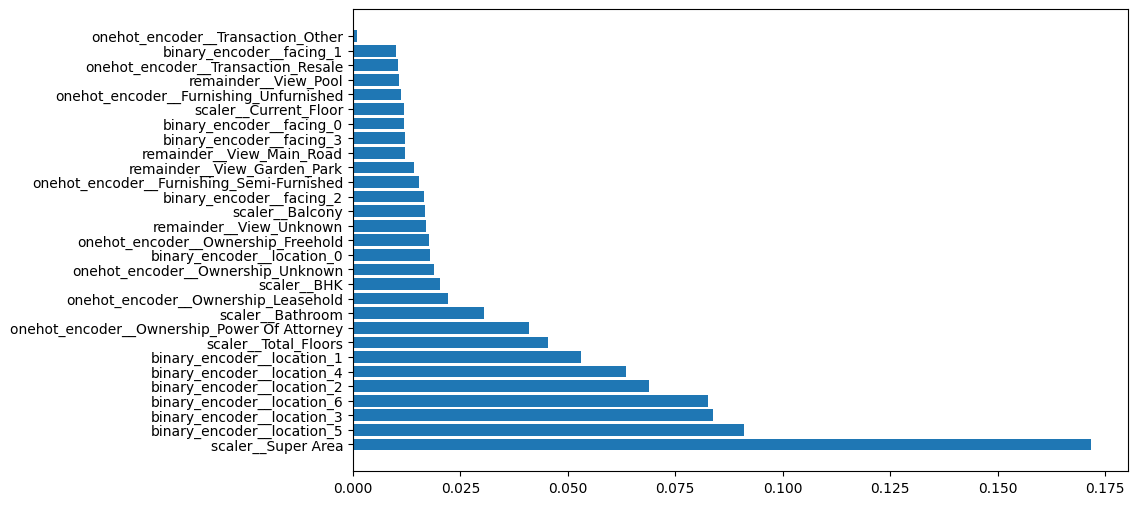

In [21]:
xgb_model = xg_best_model_cap.named_steps["model"]

feature_names = xg_best_model_cap.named_steps["preprocessor"].get_feature_names_out()

df_importance = pd.DataFrame({'Feature': feature_names,
    'Importance': xgb_model.feature_importances_}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6))
plt.barh(df_importance["Feature"], df_importance['Importance'])
plt.show()

# 📊 Experiments Summary

We conducted multiple experiments to improve model performance, robustness, and generalization:

- **Baseline (XGBoost):**  
  Delivered strong performance with slight overfitting, serving as the reference model.

- **Outliers Removal:**  
  Reduced error metrics (MAE/RMSE), but negatively impacted generalization by removing high-value properties that are important in real-world scenarios.

- **Log Transformation:**  
  Helped reduce skewness in the target variable, but did not lead to a meaningful improvement in overall performance compared to the baseline.

- **Capping (99%):**  
  Limited the impact of extreme values while preserving most of the dataset.  
  This approach achieved the best balance between accuracy and stability.

- **Feature Engineering:**  
  Added new ratio-based features such as:
  - `area_per_bhk`
  - `bathroom_per_bhk`
  - `balcony_per_bhk`  
  However, these features did not significantly improve performance, likely because tree-based models like XGBoost can already capture such relationships implicitly.

- **Multiple Models Approach (Cheap vs Expensive):**  
  The dataset was segmented into:
  - Cheap properties (≤ 9.5M)
  - Expensive properties (> 9.5M)

  Separate models were trained for each segment.  
  While training performance improved, test performance remained similar or slightly lower than the baseline, indicating limited generalization benefit and increased system complexity.

- **Ensemble (Voting Model):**  
  Combined XGBoost and Random Forest models to leverage different learning strategies.  
  However, the ensemble did not outperform the best single model, suggesting that XGBoost alone was already capturing most patterns effectively.

---

## 📏 Evaluation Strategy

Initial experiments were evaluated using **R² score** to understand overall model fit.  
For final model selection, **RMSE (Root Mean Squared Error)** was used as the primary metric, as it provides a more interpretable measure of prediction error in monetary terms.

---

# ✅ Final Decision:

We selected **XGBoost with Capping (99%)** as the final model.

This approach offers:
- Strong and stable performance
- Good generalization on unseen data
- Robust handling of extreme values
- Lower complexity compared to ensemble and multi-model solutions

Additionally, the multi-model approach (Cheap vs Expensive) is retained as an alternative deployment strategy for real-world applications where segmentation may provide better interpretability.